In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def generate_multivariate_sine_projected(T, d, latent_dim=3):
    t = np.linspace(0, 1, T)
    
    # 1. Generate K independent hidden signals
    latent_signals = np.zeros((T, latent_dim))
    for k in range(latent_dim):
        freq = np.random.uniform(2, 5) * (k + 1) # Distinct frequencies
        phase = np.random.uniform(0, 2*np.pi)
        latent_signals[:, k] = np.sin(2 * np.pi * freq * t + phase)
        
    # 2. Create a fixed Mixing Matrix (latent_dim x d)
    # This maps the 3 hidden signals to your 15 observed channels
    mixing_matrix = np.random.uniform(-1, 1, (latent_dim, d))
    
    # 3. Project the signals: (T x 3) @ (3 x 15) = (T x 15)
    X = latent_signals @ mixing_matrix
    
    # Add independent channel noise
    noise = np.random.normal(0, 0.1, (T, d))
    return X + noise

def generate_multivariate_trend(T, d):
    t = np.linspace(0,1,T)
    base_a = np.random.uniform(0.05,0.5)
    base_b = np.random.uniform(-0.5,0.5)
    
    X = np.zeros((T, d))
    
    # Pre-determine which channels have positive/negative correlation to the base
    correlations = np.random.choice([1, -1], size=d)

    for j in range(d):
        # Some channels go up, some go down, but the slope magnitude is locked
        channel_signal = (base_a * correlations[j]) * t + base_b
            
        noise = np.random.normal(0, 0.07, T)
        X[:, j] = channel_signal + noise

    return X

def generate_multivariate_var(T, d):
    Y = np.zeros((T, d))
    
    # 1. Create a sparse transition matrix A
    # The diagonal is self-dependence, off-diagonals are cross-channel dependence
    A = np.eye(d) * np.random.uniform(0.5, 0.8, d) 
    
    # Add some random cross-channel dependencies
    for _ in range(d * 2):
        i, j = np.random.randint(0, d, 2)
        if i != j:
            A[i, j] = np.random.uniform(-0.3, 0.3)
            
    # Ensure stability (eigenvalues must be < 1)
    eigenvalues = np.linalg.eigvals(A)
    max_eig = np.max(np.abs(eigenvalues))
    if max_eig >= 1:
        A = A / (max_eig + 0.01)

    # 2. Generate the sequence
    noise = np.random.normal(0, 0.3, (T, d))
    for t in range(1, T):
        Y[t] = A @ Y[t-1] + noise[t]
        
    return Y


def generate_timeseries(T=200000, d=15):
    segment_length = T // 8

    X1 = generate_multivariate_trend(segment_length, d)
    X2 = generate_multivariate_sine_projected(segment_length, d)
    X3 = generate_multivariate_var(segment_length, d)
    X4 = generate_multivariate_trend(segment_length, d)
    X5 = generate_multivariate_sine_projected(segment_length, d)
    X6 = generate_multivariate_var(segment_length, d)
    X7 = generate_multivariate_sine_projected(segment_length, d)
    X8 = generate_multivariate_trend(segment_length, d)

    # align segments
    def align(prev, curr):
        shift = prev[-1] - curr[0]
        return curr + shift

    X2 = align(X1, X2)
    X3 = align(X2, X3)
    X4 = align(X3, X4)
    X5 = align(X4, X5)
    X6 = align(X5, X6)
    X7 = align(X6, X7)
    X8 = align(X7, X8)

    X = np.vstack([X1, X2, X3, X4, X5, X6, X7, X8])

    y = np.zeros(T)
    return X, y

In [8]:
def plot_mts(X, y): #, regimes):
    T, d = X.shape
    t = np.arange(T)
    
    fig, axes = plt.subplots(5, 1, figsize=(20, 10), sharex=True)
    
    if d == 1:
        axes = [axes]
    
    for j in range(5):
        axes[j].plot(t, X[:, j])
        
        # Highlight anomalies
        anomaly_idx = np.where(y == 1)[0]
        axes[j].scatter(anomaly_idx, X[anomaly_idx, j], s=10)
        
        axes[j].set_ylabel(f"Channel {j}")
    
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

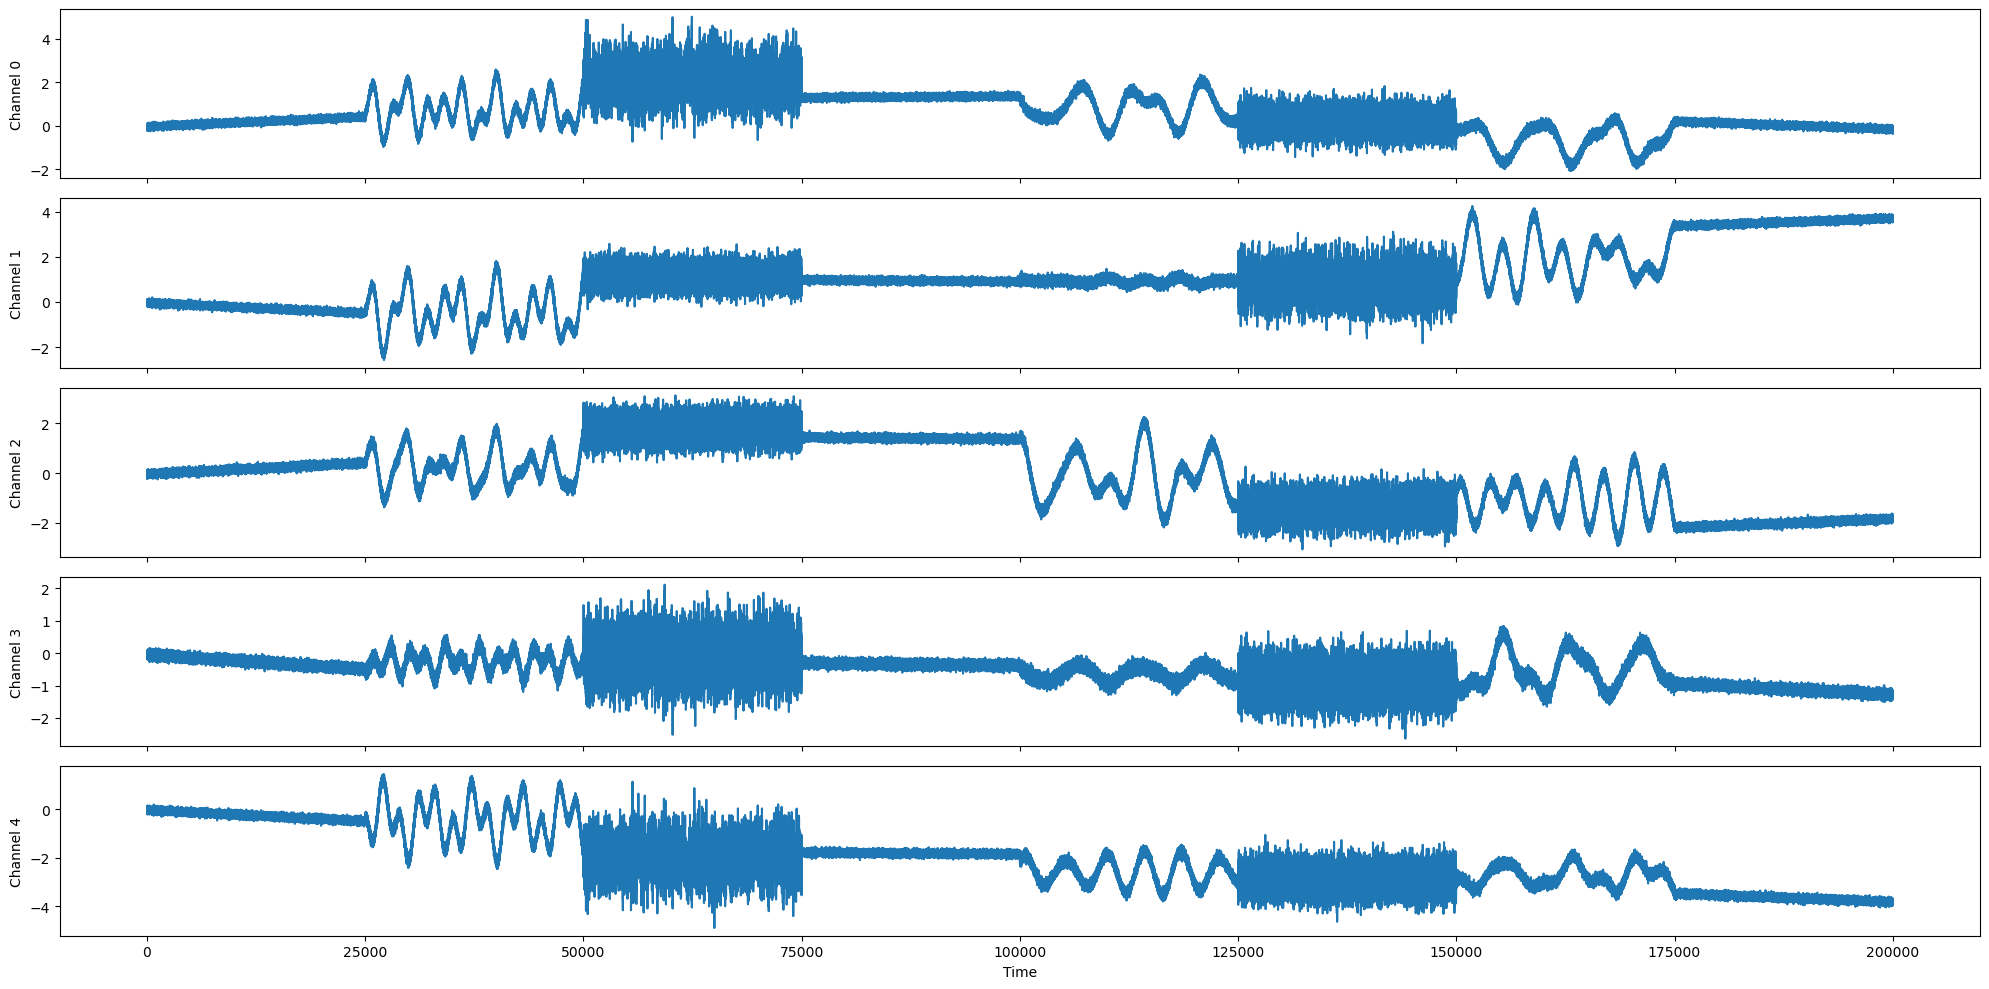

In [9]:
X,y = generate_timeseries()
plot_mts(X,y)